In [1]:
import casadi as ca
import numpy as np
import math
import control as ct
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

### Cascaded PID implementation of QuadCopter Control
Using mincopter dynamics model from `common/dynamics.py`

We use a cascaded control architecture with 12 PID controllers in total
- rate_roll
- rate_pitch
- rate_yaw
- error_roll
- error_pitch
- error_yaw
- vel_throttle
- pos_throttle
- nav_x_vel
- nav_y_vel
- nav_x_pos
- nav_y_pos

In [16]:
from common.dynamics import mincopter_dynamics

mass = 2.43
g=9.81
dt = 0.01
dynamics, lin_dynamics = mincopter_dynamics(mass=mass, dt=dt)

parms = {"Q": np.eye(12), "R": np.eye(4), "N": 10, "Qf": np.eye(12), "dynamic": True}

In [10]:
class PID:
    def __init__(self, kp, ki, kd):
        self.kp = kp
        self.ki = ki
        self.kd = kd

        self.integral = 0.0
        self.prev_error = 0.0

    def __call__(self, target, measurement, dt):
        error = target - measurement

        # Integral term
        self.integral += error * dt

        # Derivative term (protect against dt=0)
        derivative = (error - self.prev_error) / dt if dt > 0 else 0.0

        # PID output
        output = self.kp * error + self.ki * self.integral + self.kd * derivative

        # Store error for next step
        self.prev_error = error

        return output

    def reset(self):
        self.integral = 0.0
        self.prev_error = 0.0

## Controllers
rate_roll = PID(0.5,0.1,0)
rate_pitch = PID(0.5,0.1,0)
rate_yaw = PID(0.5,0.1,0)

error_roll = PID(5,0.1,0)
error_pitch = PID(5,0.1,0)
error_yaw = PID(5,0.1,0)

## Throttle controllers
vel_throttle = PID(10,0,0) ## Output is total force (zeroed at m*g)
pos_throttle = PID(1,0,0) ## Output is vertical acceleration

## Navigation controllers (technically planners)
nav_x_vel = PID(5,0,0)
nav_y_vel = PID(5,0,0)
nav_x_pos = PID(1,0,0)
nav_y_pos = PID(1,0,0)

controller_array = [rate_roll, rate_pitch, rate_yaw, error_roll, error_pitch, error_yaw, vel_throttle, pos_throttle, nav_x_vel, nav_y_vel, nav_x_pos, nav_y_pos]

In [21]:
## Simulation Setup
iterations=10*100

x_bag = np.zeros((12, iterations))
time = np.linspace(0,1,100)

## Initial conditions
temp_x = [0, 0, 10, 0.1, 0, -0.1, 0, 0, 0, 0.3, -0.3, -0.1]
temp_u = [0, 0, 0, 0]

## Control variables

# Destination (NED frame, metres)
target_x = 30
target_y = -15
target_z = -20 ## Indicates 20 metres above "ground" or "0 alt"
target_yaw = 0 ## No yawing required for our waypoint controller

## Reset all PID controllers
for c in controller_array:
    c.reset()

## Intermediate variables that we want to plot
ctx = {
    'c_roll_out': [],
    'c_pitch_out': [],
    'c_yaw_out': [],
    'c_throttle_out': [],
    'mot_0': [],
    'mot_1': [],
    'mot_2': [],
    'mot_3': [],
    'u_force': [],
    'u_rtorque': [],
    'u_ptorque': [],
    'u_ytorque': []
}

## 1 second simulation
outer = True
for j in range(0,iterations):

    if j%25==0:
        ## Run outer loop at 4Hz
        
        ## First convert from world frame target to 'yaw-corrected' frame target
        target_x_bdy = math.cos(temp_x[3])*target_x + math.sin(temp_x[3])*target_y
        target_y_bdy = -math.sin(temp_x[3])*target_x + math.cos(temp_x[3])*target_y

        ## Run outer nav loop
        x_vel_target = nav_x_pos(target_x_bdy, temp_x[0], 0.25)
        y_vel_target = nav_y_pos(target_y_bdy, temp_x[1], 0.25)
                
    if j%5==0 and outer:
        ## Run nav loop @ 20Hz
        x_accel_target = nav_x_vel(x_vel_target, temp_x[6], 0.05)
        y_accel_target = nav_y_vel(y_vel_target, temp_x[7], 0.05)

        ## Convert accel targets to angles
        if temp_u[0]==0:
            temp_as_x = 0
            temp_as_y = 0
        else:
            ## NOTE Check this math as I don't this this conversion from force to accel is correct
            temp_as_x = -1*x_accel_target / (temp_u[0])
            temp_as_y = y_accel_target / (temp_u[0])

        temp_as_x = min(max(temp_as_x, -1), 1)
        temp_as_y = min(max(temp_as_y, -1), 1)

        desired_roll = math.asin(temp_as_y)
        desired_pitch = math.asin(temp_as_x)
        
        ## Run outer loop
        #roll_rate_target = error_roll(0, temp_x[3], 0.05)
        #pitch_rate_target = error_pitch(0, temp_x[4], 0.05)
        roll_rate_target = error_roll(desired_roll, temp_x[3], 0.05)
        pitch_rate_target = error_pitch(desired_pitch, temp_x[4], 0.05)
        
        yaw_rate_target = error_yaw(0, temp_x[5], 0.05)

        ## Run throttle pos
        #vert_vel_target = pos_throttle(-20, temp_x[2], 0.05)
        vert_vel_target = pos_throttle(5, temp_x[2], 0.05)
    elif not outer:
        roll_rate_target = 0
        pitch_rate_target = 0
        yaw_rate_target = 0

        vert_vel_target = 0        
        
    rroll_current = temp_x[9]
    rpitch_current = temp_x[10]
    ryaw_current = temp_x[11]
    
    rt = rate_roll(roll_rate_target, rroll_current, 0.01)
    pt = rate_pitch(pitch_rate_target, rpitch_current, 0.01) 
    yt = rate_yaw(yaw_rate_target, ryaw_current, 0.01)

    ## Run throttle vel
    tforce = vel_throttle(vert_vel_target, temp_x[8], 0.01)
    tforce *= -1

    ## Our dynamics linearisation is around Force=mass*g so we add mass*g back in here
    temp_u = [mass*g + tforce, rt, pt, yt]
    
    ## Constrain force between [0,20] : 0 is no throttle and 20 is full throttle
    if temp_u[0]<0:
        temp_u[0]=0
    elif temp_u[0]>50:
        temp_u[0]=50
    
    # Store intermediate variables
    ctx['u_force'].append(temp_u[0])
    ctx['u_rtorque'].append(temp_u[1])
    ctx['u_ptorque'].append(temp_u[2])
    ctx['u_ytorque'].append(temp_u[3])

    # Feed dynamics
    temp_x = dynamics(temp_x, temp_u).full()

    # Wrap roll/pitch/yaw
    ## TODO

    # Record output for plotting
    x_bag[:, j] = temp_x.reshape((12,))
    temp_x = temp_x.reshape((12,))


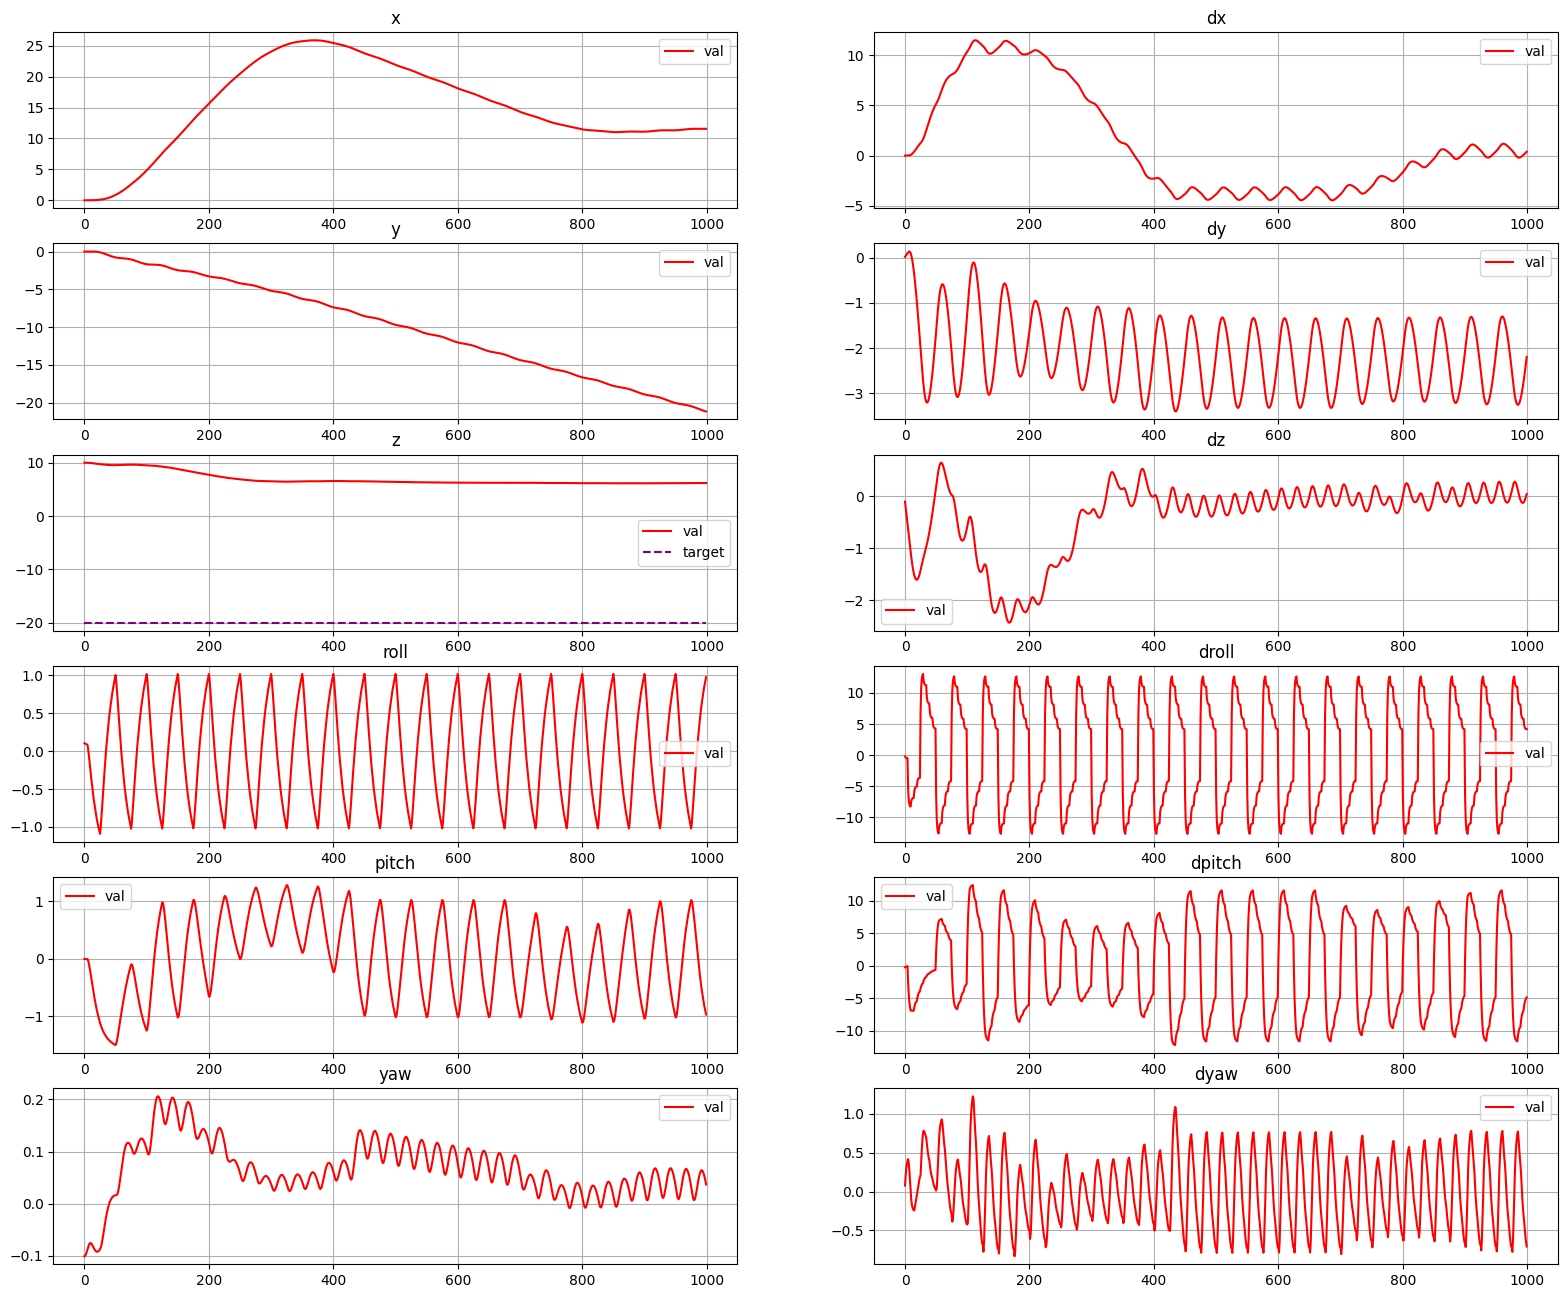

In [22]:
# Visualisation - State Variables
fig = plt.figure(figsize=(30, 16))
gs = GridSpec(6, 3, figure=fig)

for i,title in enumerate(['x','y','z','roll','pitch','yaw','dx','dy','dz','droll','dpitch','dyaw']):
    ax = fig.add_subplot(gs[i%6,i//6])
    t = range(0,x_bag[i,:].shape[0])
    ax.plot(t, x_bag[i,:], color='red', label='val')
    if title=='z':
        ax.plot(t, len(t)*[-20], color='purple', linestyle='--', label='target')
    ax.set_title(title)
    ax.grid()
    ax.legend()

plt.show()

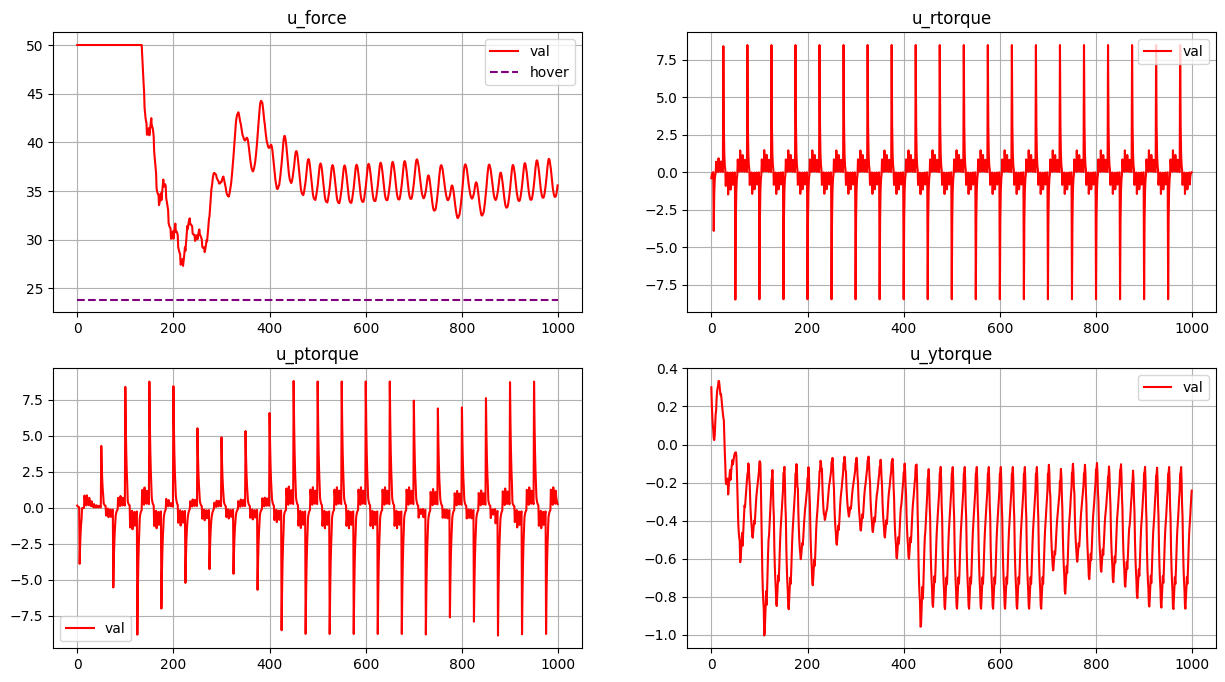

In [23]:
# Visualisation - State Variables
fig = plt.figure(figsize=(15, 8))
gs = GridSpec(2, 2, figure=fig)

for i,title in enumerate(['u_force', 'u_rtorque', 'u_ptorque', 'u_ytorque']):
    ax = fig.add_subplot(gs[i//2, i%2])
    t = range(0,len(ctx[title]))
    ax.plot(t, ctx[title], color='red', label='val')
    if title=='u_force':
        ax.plot(t, len(t)*[mass*g], color='purple', linestyle='--', label='hover')
    ax.set_title(title)
    ax.grid()
    ax.legend()

plt.show()